This Colab notebook is designed to evaluate Gemini's transcription performance relative to other models the team has previously analyzed.

**Note:** Rather than using [NeMo's](https://www.nvidia.com/en-us/ai-data-science/products/nemo/) implementation of WER, this Colab uses [JiWER](https://github.com/jitsi/jiwer) since it is lighterweight and usable in a vanilla Colab instance.

The Colab performs the following functions:

1.  **Defines helper functions** for advanced text normalization, specifically handling numbers (digit-to-word expansion), removing annotations (e.g., `<bracketed_text>`), and filtering dispatcher-specific filler words for accurate WER calculation.
2.  **Parses Gemini transcription output** from GCS, which utilizes a flat JSON structure with a top-level `"transcription"` key, replacing older nested result formats.
3.  **Generates and visualizes a WER leaderboard** comparing different ASR models (Gemini 3.1 Pro Preview, Parakeet v2, Canary Flash) based on the merged data.
4.  **Exports the updated benchmark** (including Gemini's predictions) back to Google Cloud Storage. This output is formatted using NeMo's manifest format (JSONL) for downstream tool compatibility.

Note: This Colab reads/writes content in the `wd-asr-chirp-evaluation` bucket in GCP.

In [2]:
# @title Install dependencies
!pip install -q jiwer num2words loguru

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.4 MB/s eta 0:00:00


In [3]:
# @title Imports, constants, and auth
import json
import re
import os
import collections
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import jiwer
from num2words import num2words
from google.colab import auth
from google.cloud import storage
from loguru import logger
from typing import Any

GCP_PROJECT_ID = "automatic-hawk-481415-m9"
GCS_BUCKET = "wd-asr-chirp-evaluation"
MODEL_ID = "gemini-3.1-pro-preview"
MODEL_VERSION=re.sub(r'[-\.]', '_', MODEL_ID)
GCS_OUTPUT_DIR = f"{MODEL_VERSION}_transcripts"
GCS_MAP_DIR = "segmented_audio"
BATCH_MANIFEST_FILENAME = "batch_manifest.jsonl"
EXISTING_BENCHMARK_FILENAME = "playground_parakeet_and_canary_flash.json"
UPDATED_BENCHMARK_FILENAME = f"playground_parakeet_and_canary_flash_and_{MODEL_VERSION}.jsonl"

# Authenticate to GCS
auth.authenticate_user()
!gcloud config set project {GCP_PROJECT_ID} --quiet

Updated property [core/project].


To take a quick anonymous survey, run:
  $ gcloud survey



In [8]:
# @title Defining helper functions
class ExpandNumbersToWords(jiwer.AbstractTransform):
    def process_string(self, s: str) -> str:
        # Convert digits to words: "433" -> "four hundred and thirty-three"
        def replace_digits(match: re.Match) -> str:
            word_form = num2words(match.group(0))
            # Clean up the output so "thirty-three" matches "thirty three"
            return word_form.replace("-", " ").replace(",", "").replace(" and ", " ")

        return re.sub(r"\d+", replace_digits, s)

class RemoveAnnotations(jiwer.AbstractTransform):
    def process_string(self, s: str) -> str:
        # Surgically removes <anything> or [anything] even if touching punctuation
        s = re.sub(r"<[^>]+>", "", s)
        s = re.sub(r"\[[^\]]+\]", "", s)
        return s

class NormalizeDispatchQuirks(jiwer.AbstractTransform):
    def process_string(self, s: str) -> str:
        # Strip underscore placeholders (treat like <unknown>)
        s = re.sub(r"_+", "", s)

        # Strip fillers (uh, um, ah, er) so models aren't penalized for readability
        s = re.sub(r"\b(uh|um|ah|er)\b", "", s, flags=re.IGNORECASE)

        # Turn hyphens into spaces (e.g., "14A-alpha" -> "14A alpha")
        # Prevents words from getting glued together when punctuation is removed
        s = s.replace("-", " ")

        return s

def load_manifest(path: str) -> list[dict[str, Any]]:
    """Helper to load manifest. Cleans up formatting issues and stray linefeeds."""
    data = []
    if not os.path.exists(path):
        logger.error(f"Manifest path not found: {path}")
        return []

    with open(path, "r", encoding="utf-8") as f:
        content = f.read().strip()

    # Handle JSON array format
    if content.startswith("["):
        try:
            data = json.loads(content)
        except json.JSONDecodeError as e:
            logger.error(f"Failed to parse JSON array: {e}")
            return []
    else:
        # Safely split JSONL even if there are literal newlines inside the strings
        raw_objects = re.split(r"}\s*\n\s*{", content)
        for i, obj_str in enumerate(raw_objects):
            # Re-add braces stripped by the regex split
            if not obj_str.startswith("{"): obj_str = "{" + obj_str
            if not obj_str.endswith("}"): obj_str = obj_str + "}"
            try:
                data.append(json.loads(obj_str))
            except json.JSONDecodeError:
                logger.warning(f"Skipping malformed JSON object at index {i}")

    return data

def merge_gcs_results_to_manifest(
    baseline_data: list[dict[str, Any]],
    batch_manifest_data: list[dict[str, Any]],
    gcs_bucket_name: str,
    output_file: str
) -> list[dict[str, Any]]:
    client = storage.Client(project=GCP_PROJECT_ID)
    bucket = client.bucket(gcs_bucket_name)

    logger.info(f"Fetching Gemini transcripts from gs://{gcs_bucket_name}/{GCS_OUTPUT_DIR}/...")
    transcript_blobs = list(bucket.list_blobs(prefix=f"{GCS_OUTPUT_DIR}/"))

    gemini_predictions = {}
    for blob in transcript_blobs:
        if not blob.name.endswith(".json"): continue

        match = re.search(r"([^/]+)__seg(\d{3})", os.path.basename(blob.name))
        if not match: continue

        example_id = match.group(1)
        seg_key = match.group(2)

        try:
            data = json.loads(blob.download_as_text())
            if "transcription" in data:
                gemini_predictions[(example_id, seg_key)] = data["transcription"].strip()
        except Exception as e:
            logger.error(f"Error downloading/parsing {blob.name}: {e}")

    offset_to_seg = collections.defaultdict(dict)
    for entry in batch_manifest_data:
        e_id = entry.get("example_id", "")
        s_id = entry.get("segment_id", "")
        offset = float(entry.get("offset", 0.0))
        offset_to_seg[e_id][offset] = s_id

    merged_records = []
    unmatched_count = 0
    EPSILON = 0.001

    for b_info in baseline_data:
        example_id = os.path.splitext(os.path.basename(b_info["audio_filepath"]))[0]
        b_offset = float(b_info.get("offset", 0.0))

        gemini_text = ""
        matched_seg_id = None

        # Epsilon matching logic
        available_offsets = offset_to_seg.get(example_id, {})
        for off_val, s_id in available_offsets.items():
            if abs(off_val - b_offset) <= EPSILON:
                matched_seg_id = s_id
                break

        if matched_seg_id and (example_id, matched_seg_id) in gemini_predictions:
            gemini_text = gemini_predictions[(example_id, matched_seg_id)]
        else:
            unmatched_count += 1
            logger.warning(f"Missed Match: No transcript found for {example_id} at offset {b_offset}")

        record = {
            "audio_filepath": b_info["audio_filepath"],
            "text": b_info.get("text", ""),
            f"pred_text_{MODEL_VERSION}": gemini_text,
            "pred_text_parakeet-tdt-06b-v2": b_info.get("pred_text_parakeet-tdt-06b-v2", ""),
            "pred_text_canary-1b-flash": b_info.get("pred_text_canary-1b-flash", ""),
            "duration": b_info.get("duration", 0.0),
            "offset": b_offset,
            "lang": b_info.get("lang", "en")
        }
        merged_records.append(record)

    if unmatched_count > 0:
        logger.error(f"WARNING: {unmatched_count} benchmark rows failed to map!")

    with open(output_file, "w", encoding="utf-8") as f_out:
        for rec in merged_records:
            f_out.write(json.dumps(rec) + "\n")

    return merged_records

def generate_leaderboard(manifest_path: str) -> pd.DataFrame:
    manifest_data = load_manifest(manifest_path)
    if not manifest_data:
        raise ValueError(f"No data found in manifest: {manifest_path}. Cannot generate leaderboard.")

    refs = [d["text"] for d in manifest_data]
    gemini_hyps = [d[f"pred_text_{MODEL_VERSION}"] for d in manifest_data]
    parakeet_hyps = [d["pred_text_parakeet-tdt-06b-v2"] for d in manifest_data]
    canary_hyps = [d["pred_text_canary-1b-flash"] for d in manifest_data]

    radio_pipeline = jiwer.Compose([
        ExpandNumbersToWords(),
        RemoveAnnotations(),
        NormalizeDispatchQuirks(),
        # Remove linefeeds, returns and tabs
        jiwer.SubstituteRegexes({r"[\n\r\t]+": " "}),
        jiwer.ToLowerCase(),
        jiwer.ExpandCommonEnglishContractions(),
        jiwer.RemovePunctuation(),
        jiwer.RemoveWhiteSpace(replace_by_space=True),
        jiwer.RemoveMultipleSpaces(),
        jiwer.Strip(),
        jiwer.ReduceToListOfListOfWords()
    ])

    results = {
        "Gemini 3": jiwer.wer(refs, gemini_hyps, radio_pipeline, radio_pipeline) * 100,
        "Parakeet v2": jiwer.wer(refs, parakeet_hyps, radio_pipeline, radio_pipeline) * 100,
        "Canary Flash": jiwer.wer(refs, canary_hyps, radio_pipeline, radio_pipeline) * 100
    }

    df = pd.DataFrame(list(results.items()), columns=["Model", "WER (%)"]).sort_values("WER (%)")
    logger.info("\nUpdated Benchmark Results\n")

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Model", y="WER (%)", hue="Model", data=df, palette="viridis", legend=False)
    for index, value in enumerate(df["WER (%)"]):
        plt.text(index, value + 0.5, f"{value:.2f}%", ha="center", fontweight="bold")
    plt.title("Word Error Rate (WER) by Model", fontsize=14)
    plt.show()

    return df

def run_evaluation_pipeline() -> pd.DataFrame:
    # Download and load the ground truth benchmark (Parakeet/Canary baseline)
    if not os.path.exists(EXISTING_BENCHMARK_FILENAME):
        gcs_path = EXISTING_BENCHMARK_FILENAME
        storage.Client(project=GCP_PROJECT_ID).bucket(GCS_BUCKET).blob(gcs_path).download_to_filename(EXISTING_BENCHMARK_FILENAME)

    baseline_data = load_manifest(EXISTING_BENCHMARK_FILENAME)
    if not baseline_data:
        raise ValueError(f"Manifest path not found: {EXISTING_BENCHMARK_FILENAME}. Please ensure the file exists and is accessible.")

    # Download and load the batch manifest from segmentation Colab to map the offsets
    if not os.path.exists(BATCH_MANIFEST_FILENAME):
        gcs_path = f"{GCS_MAP_DIR}/{BATCH_MANIFEST_FILENAME}"
        storage.Client(project=GCP_PROJECT_ID).bucket(GCS_BUCKET).blob(gcs_path).download_to_filename(BATCH_MANIFEST_FILENAME)

    batch_manifest_data = load_manifest(BATCH_MANIFEST_FILENAME)
    # Merge Gemini's predictions into the baseline and generate the leaderboard
    merge_gcs_results_to_manifest(baseline_data, batch_manifest_data, GCS_BUCKET, UPDATED_BENCHMARK_FILENAME)
    return generate_leaderboard(UPDATED_BENCHMARK_FILENAME)

def export_master_playground() -> None:
    # Upload the final manifest to GCS
    storage.Client(project=GCP_PROJECT_ID).bucket(GCS_BUCKET).blob(UPDATED_BENCHMARK_FILENAME).upload_from_filename(UPDATED_BENCHMARK_FILENAME)

2026-03-12 20:44:40.265 | INFO     | __main__:merge_gcs_results_to_manifest:73 - Fetching Gemini transcripts from gs://wd-asr-chirp-evaluation/gemini_3_1_pro_preview_transcripts/...
2026-03-12 20:44:43.806 | INFO     | __main__:generate_leaderboard:177 - 
Updated Benchmark Results



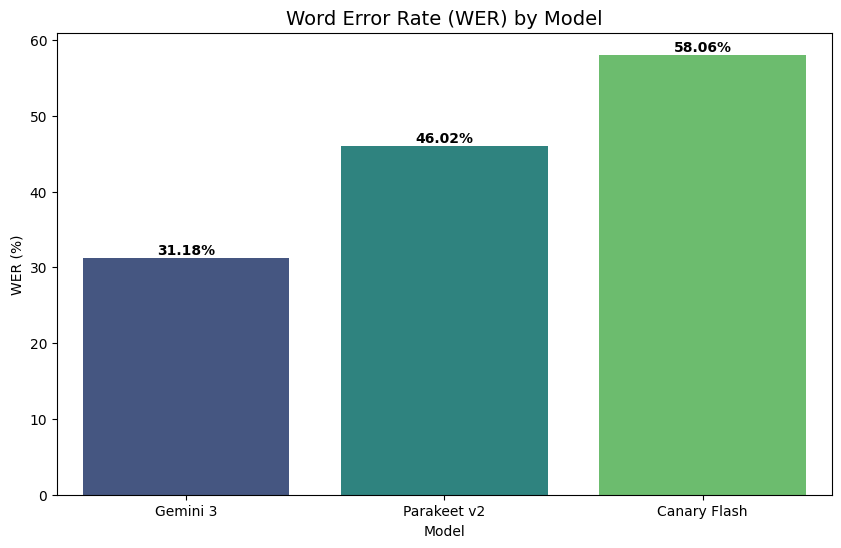

,Model,WER (%)
0,Gemini 3,31.182796
1,Parakeet v2,46.021505
2,Canary Flash,58.064516


In [9]:
# @title Compare Gemini performance and output the updated playground manifest
df_leaderboard = run_evaluation_pipeline()

export_master_playground()

df_leaderboard